In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
train = pd.read_csv('../data/train_final.csv')
test = pd.read_csv('../data/test_final.csv')

In [27]:
train.head()

,text_1,text_2,label,num_chars_1,num_words_1,num_sentences_1,avg_word_length_1,avg_sentence_length_1,num_chars_2,num_words_2,num_sentences_2,avg_word_length_2,avg_sentence_length_2
0,The VIRSA (Visible Infrared Survey Telescope A...,The China relay network has released a signifi...,0,2196.0,322.0,9.0,6.819876,35.777778,2018.0,323.0,10.0,6.247678,32.300000
1,China\nThe goal of this project involves achie...,The project aims to achieve an accuracy level ...,1,3124.0,497.0,8.0,6.285714,62.125000,936.0,153.0,4.0,6.117647,38.250000
2,Scientists can learn about how galaxies form a...,Dinosaur eggshells offer clues about what dino...,0,1139.0,171.0,3.0,6.660819,57.000000,801.0,133.0,3.0,6.022556,44.333333
3,China\nThe study suggests that multiple star s...,The importance for understanding how stars evo...,1,1774.0,313.0,8.0,5.667732,39.125000,1869.0,271.0,6.0,6.896679,45.166667
4,Dinosaur Rex was excited about his new toy set...,Analyzing how fast stars rotate within a galax...,1,195.0,38.0,3.0,5.131579,12.666667,871.0,138.0,4.0,6.311594,34.500000


In [28]:
train['label'].value_counts()

label
0    95
1    95
Name: count, dtype: int64

In [29]:
train.columns

Index(['text_1', 'text_2', 'label', 'num_chars_1', 'num_words_1',
       'num_sentences_1', 'avg_word_length_1', 'avg_sentence_length_1',
       'num_chars_2', 'num_words_2', 'num_sentences_2', 'avg_word_length_2',
       'avg_sentence_length_2'],
      dtype='object')

In [30]:
features = ['num_chars_1', 'num_words_1',
       'num_sentences_1', 'avg_word_length_1', 'avg_sentence_length_1',
       'num_chars_2', 'num_words_2', 'num_sentences_2', 'avg_word_length_2',
       'avg_sentence_length_2']

target = 'label'

In [31]:
X = train[features]
y = train[target]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)


CV accuracy: 0.842 ± 0.030
CV roc_auc:  0.930 ± 0.024
ROC AUC: 0.9318181818181818


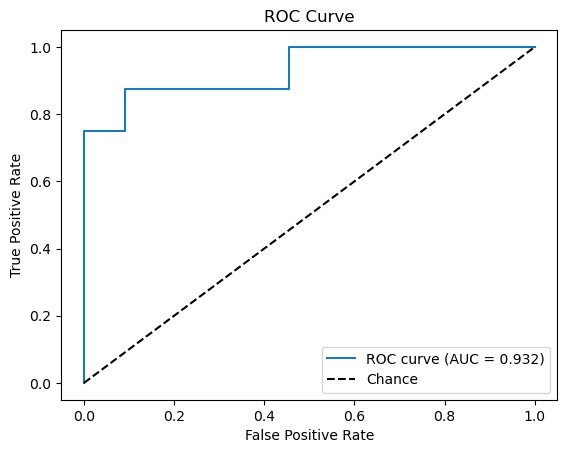

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        11
           1       0.78      0.88      0.82         8

    accuracy                           0.84        19
   macro avg       0.84      0.85      0.84        19
weighted avg       0.85      0.84      0.84        19

[[9 2]
 [1 7]]
0.8421052631578947


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import cross_validate, StratifiedKFold

log_reg = LogisticRegression(solver='liblinear', random_state=42)

log_reg.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc']

cv_results = cross_validate(log_reg, X_train, y_train, cv=cv, scoring=scoring)
print(f"CV accuracy: {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"CV roc_auc:  {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}")

y_pred = log_reg.predict(X_val)

# probabilities for the positive class
y_prob = log_reg.predict_proba(X_val)[:, 1]

# compute AUC
auc = roc_auc_score(y_val, y_prob)
print("ROC AUC:", auc)

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))
print(accuracy_score(y_val, y_pred))

In [38]:
y_pred_test = log_reg.predict(test[features])

result = pd.DataFrame({'id': range(len(y_pred_test)), 'real_text_id': y_pred_test + 1})
result.to_csv('../data/submissions/log_reg_with_new_features.csv', index=False)

CV accuracy: 0.801 ± 0.029
CV roc_auc:  0.898 ± 0.024
ROC AUC: 0.8011363636363636


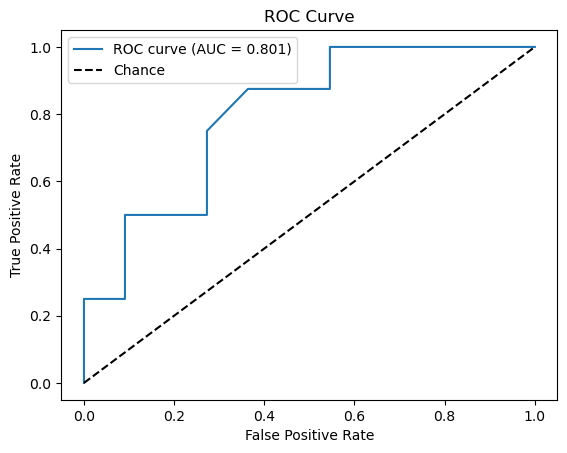

              precision    recall  f1-score   support

           0       0.67      0.73      0.70        11
           1       0.57      0.50      0.53         8

    accuracy                           0.63        19
   macro avg       0.62      0.61      0.61        19
weighted avg       0.63      0.63      0.63        19

[[8 3]
 [4 4]]
0.631578947368421


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

rf_clf.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc']

cv_results = cross_validate(rf_clf, X_train, y_train, cv=cv, scoring=scoring)
print(f"CV accuracy: {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"CV roc_auc:  {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}")

y_pred = rf_clf.predict(X_val)

# probabilities for the positive class
y_prob = rf_clf.predict_proba(X_val)[:, 1]

# compute AUC
auc = roc_auc_score(y_val, y_prob)
print("ROC AUC:", auc)

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))
print(accuracy_score(y_val, y_pred))

In [40]:
y_pred_test = rf_clf.predict(test[features])

result = pd.DataFrame({'id': range(len(y_pred_test)), 'real_text_id': y_pred_test + 1})
result.to_csv('../data/submissions/rf_clf_with_new_features.csv', index=False)